
# 💳 Credit Card Fraud Detection using Machine Learning

## 📌 Project Overview

This project focuses on detecting fraudulent credit card transactions using advanced machine learning techniques on a highly imbalanced dataset.

The workflow includes data preprocessing, exploratory data analysis (EDA), feature scaling, handling class imbalance using SMOTE, dimensionality reduction using PCA, and model training with and without PCA to evaluate performance differences.

Multiple classification models were implemented, including:

Logistic Regression (baseline model)
Random Forest (ensemble model)
XGBoost (boosting model)

Additionally, the project explores:

ROC Curve and AUC Score
Threshold tuning to balance precision and recall
Hyperparameter tuning using GridSearchCV

The main objective is to build a robust fraud detection system that maximizes recall (detecting fraud cases) while maintaining acceptable precision.

---

## 📊 Dataset Description

The dataset contains anonymized transaction data:

* Features `V1` to `V28` are transformed using PCA for confidentiality
* `Time`: Seconds elapsed between transactions
* `Amount`: Transaction amount
* `Class` (Target):

  * `0` → Normal transaction
  * `1` → Fraudulent transaction

The dataset is highly imbalanced, making traditional accuracy metrics insufficient.

---

## 🧹 Data Preprocessing

* Checked and handled missing values
* Removed duplicate records
* Analyzed class distribution
* Separated data into features (`X`) and target (`y`)
* Applied **train-test split with stratification**
---

## 📊 Exploratory Data Analysis (EDA)

* Visualized class distribution using Plotly
* Generated correlation heatmap
* Explored transaction time distribution
* Compared fraud vs normal transaction patterns
* Used boxplots to identify outliers in selected features

---

## ⚙️ Feature Scaling

Applied **StandardScaler** to normalize feature values, which is especially important for models like Logistic Regression.

---

## ⚖️ Handling Imbalanced Data

To address class imbalance, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied on the training data to generate synthetic fraud samples and balance the dataset.

---

## 🤖 Models Implemented

### 1. Logistic Regression (Baseline Model)

* Used as a baseline model
* Applied class weighting to handle imbalance
* Achieved high recall but low precision

### 2. Random Forest

* Ensemble learning method using multiple decision trees
* Provided strong performance with balanced precision and recall
* Efficient in handling complex patterns

### 3. XGBoost

* Gradient boosting algorithm
* Designed to improve performance by learning from previous errors
* Expected to outperform other models in imbalanced datasets

---

## 📈 Model Evaluation

Models were evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

Special emphasis was placed on:

* **Recall** → Detecting fraudulent transactions
* **Precision** → Reducing false positives


# Import LIBs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import precision_score,recall_score, confusion_matrix, f1_score,accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Preprocessing + Cleaning

### Handle Missing Values

In [7]:
# Check Nulls
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Handle Duplicates

In [8]:
# Find Duplicates
df.duplicated().sum()

np.int64(1081)

In [9]:
df=df.drop_duplicates()

In [10]:
df.Class.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [11]:
normal = df[df.Class == 0]
fraud = df[df.Class == 1]

In [12]:
print("Normal Shape :",normal.shape)
print("Fraud Shape :",fraud.shape)

Normal Shape : (283253, 31)
Fraud Shape : (473, 31)


In [13]:
normal_ratio = len(normal)/len(df)*100
normal_ratio

99.83328986416473

In [14]:
fraud_ratio = len(fraud)/len(df)*100
fraud_ratio


0.1667101358352777

In [15]:
normal.Amount.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [16]:
fraud.Amount.describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## Explore Data Analysis(EDA)

In [17]:
class_counts = df['Class'].value_counts().sort_index()
class_labels = ['Normal', 'Fraud']
colors = ['skyblue', 'orange']

fig = go.Figure(data=[
    go.Bar(
        x=class_labels,
        y=class_counts.values,
        marker_color=colors,
        text=class_counts.values,
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Count: %{y:,}<extra></extra>'
    )
])

fig.update_layout(
    title={
        'text': 'Class Distribution',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='Class',
    yaxis=dict(
        title='Count',
        tickformat=',',   
    ),  
    template='plotly_white',
    width=700,
    height=500,
    showlegend=False
)

fig.show()

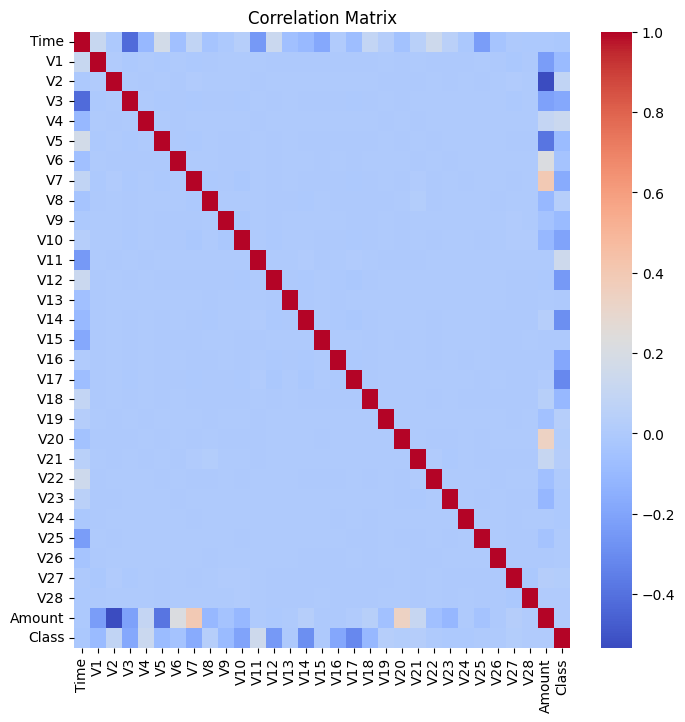

In [18]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

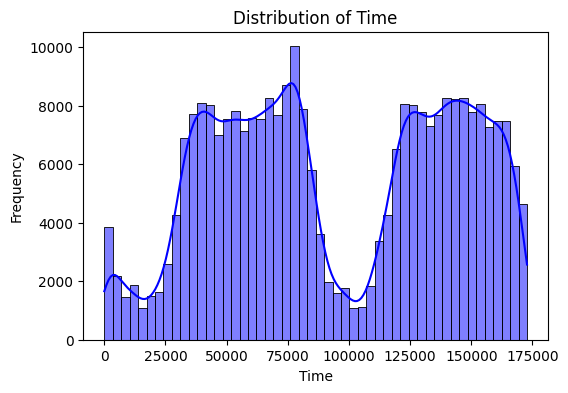

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Time'], bins=50, kde=True, color='blue')
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

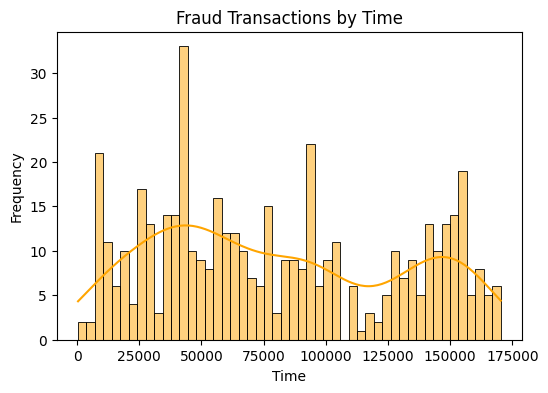

In [20]:
plt.figure(figsize=(6, 4))
sns.histplot(fraud['Time'], bins=50, kde=True, color='orange')
plt.title('Fraud Transactions by Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

## Splitting

In [21]:
X = df.drop(columns='Class')

y=df['Class']

In [22]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

## Scaling

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Imbalance Handling( SMOTE )

In [24]:
# ================= NO PCA DATA =================
smote_no_pca = SMOTE(random_state=42)

X_train_resampled_no_pca, y_train_resampled_no_pca = smote_no_pca.fit_resample(
    X_train_scaled, y_train
)

## Dimensionality Reduction (PCA)


In [25]:
from sklearn.decomposition import PCA

smote = SMOTE(random_state=42)
X_train_resampled_scaled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_resampled_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [26]:
print("Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance: 0.9391840753228393


## Logistic Regression(Baseline Model With PCA)

In [27]:
# Call
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
# Fit
lr.fit(X_train_pca, y_train_resampled)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [28]:
y_pred_lr = lr.predict(X_test_pca)

## Logistic Regression(Baseline Model Without PCA)

In [29]:
lr_no_pca = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_no_pca.fit(X_train_resampled_no_pca, y_train_resampled_no_pca)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [30]:
y_pred_lr_no_pca = lr_no_pca.predict(X_test_scaled)

## Random Forest (PCA)

In [31]:
#call
rf = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=None,n_jobs=-1)
#fit
rf.fit(X_train_pca, y_train_resampled)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred_rf = rf.predict(X_test_pca)

## Random Forest (No PCA)

In [33]:
rf_no_pca = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=None,n_jobs=-1)
rf_no_pca.fit(X_train_resampled_no_pca, y_train_resampled_no_pca)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred_rf_no_pca = rf_no_pca.predict(X_test_scaled)

## XGboost (PCA)

In [35]:
scale_pos_weight = len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])
print(scale_pos_weight)

1.0


In [36]:
# Call
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

In [37]:
# Fit
xgb.fit(X_train_pca, y_train_resampled)

y_pred_xgb = xgb.predict(X_test_pca)

## XGboost (No PCA)

In [38]:
scale_pos_weight_no_pca = len(y_train_resampled_no_pca[y_train_resampled_no_pca == 0]) / len(y_train_resampled_no_pca[y_train_resampled_no_pca == 1])

In [39]:
xgb_no_pca = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_no_pca,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss')
xgb_no_pca.fit(X_train_resampled_no_pca, y_train_resampled_no_pca)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [40]:
y_pred_xgb_no_pca = xgb_no_pca.predict(X_test_scaled)

## Feature Importance

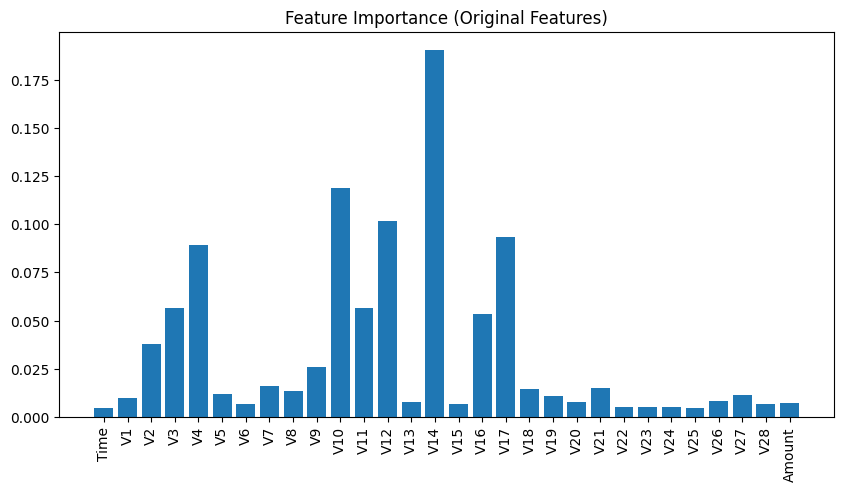

In [41]:
importances = rf_no_pca.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance (Original Features)")
plt.show()

## ROC Curve + AUC

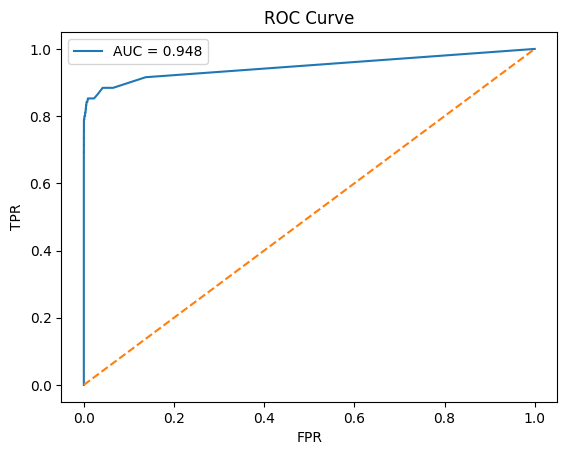

In [42]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test_pca)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC Curve")
plt.show()

In [43]:
print("AUC Score:", roc_auc)

AUC Score: 0.9476064435151884


## Threshold Tuning

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(f"\nThreshold = {t}")
    print("Precision:", precision_score(y_test, y_pred_thresh))
    print("Recall:", recall_score(y_test, y_pred_thresh))


Threshold = 0.3
Precision: 0.4550898203592814
Recall: 0.8

Threshold = 0.4
Precision: 0.5952380952380952
Recall: 0.7894736842105263

Threshold = 0.5
Precision: 0.6880733944954128
Recall: 0.7894736842105263

Threshold = 0.6
Precision: 0.7575757575757576
Recall: 0.7894736842105263

Threshold = 0.7
Precision: 0.8588235294117647
Recall: 0.7684210526315789


## Hyperparameter Tuning

In [45]:
# ================= Hyperparameter Tuning =================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 10]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train_resampled)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


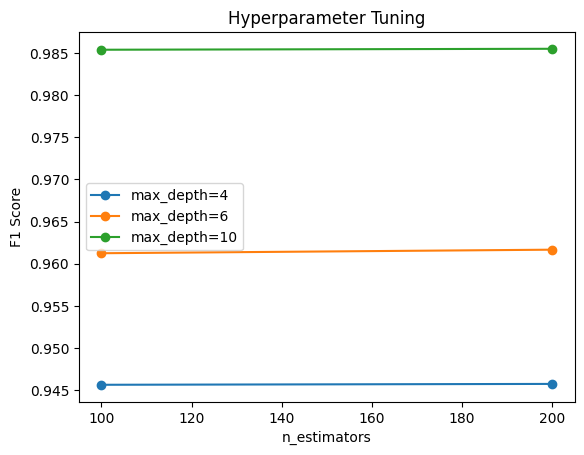

In [46]:
results = pd.DataFrame(grid.cv_results_)

for depth in results['param_max_depth'].unique():
    subset = results[results['param_max_depth'] == depth]
    
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'],marker="o",label=f"max_depth={depth}")

plt.xlabel("n_estimators")
plt.ylabel("F1 Score")
plt.title("Hyperparameter Tuning")
plt.legend()
plt.show()

## Comparisons Between Models

In [ ]:
data_no_pca = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_no_pca),
        accuracy_score(y_test, y_pred_rf_no_pca),
        accuracy_score(y_test, y_pred_xgb_no_pca)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr_no_pca),
        precision_score(y_test, y_pred_rf_no_pca),
        precision_score(y_test, y_pred_xgb_no_pca)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr_no_pca),
        recall_score(y_test, y_pred_rf_no_pca),
        recall_score(y_test, y_pred_xgb_no_pca)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr_no_pca),
        f1_score(y_test, y_pred_rf_no_pca),
        f1_score(y_test, y_pred_xgb_no_pca)
    ]
}

data_pca = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

df_before = pd.DataFrame(data_no_pca).set_index("Model")
df_after = pd.DataFrame(data_pca).set_index("Model")

print("=== Before PCA ===")
print(df_before)
print("\n=== After PCA ===")
print(df_after)


=== Before PCA ===
                     Accuracy  Precision    Recall  F1-Score
Model                                                       
Logistic Regression  0.973672   0.053035  0.873684  0.100000
Random Forest        0.999489   0.912500  0.768421  0.834286
XGBoost              0.999225   0.747573  0.810526  0.777778

=== After PCA ===
                     Accuracy  Precision    Recall  F1-Score
Model                                                       
Logistic Regression  0.975170   0.054878  0.852632  0.103119
Random Forest        0.999101   0.707547  0.789474  0.746269
XGBoost              0.997039   0.340611  0.821053  0.481481


In [50]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score'] 
titles = ("📊 Accuracy Comparison", "🔍 Precision Comparison", 
        "🎯 Recall Comparison", "⚖️ F1-Score Comparison")
positions = [(1,1), (1,2), (2,1), (2,2)]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=titles,
    horizontal_spacing=0.1,
    vertical_spacing=0.15
)

for i, metric in enumerate(metrics):
    row, col = positions[i]
    

    fig.add_trace(
        go.Bar(
            x=df_before.index,
            y=df_before[metric],
            name='No PCA',
            marker_color='#3498db', 
            hovertemplate='Model: %{x}<br>Value: %{y:.4f}<extra></extra>'
        ),
        row=row, col=col
    )
    
    fig.add_trace(
        go.Bar(
            x=df_after.index,
            y=df_after[metric],
            name='PCA',
            marker_color='#e74c3c', 
            hovertemplate='Model: %{x}<br>Value: %{y:.4f}<extra></extra>'
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text="<b>📈 Model Performance Comparison: Before vs After PCA</b>",
    title_x=0.5,
    height=800,
    showlegend=True,
    barmode='group',
    template='plotly_white'
)

names = set()
fig.for_each_trace(
    lambda trace: trace.update(showlegend=False) if trace.name in names else names.add(trace.name)
)

fig.show()


## 🏆 Key Results & Insights

* **Random Forest** showed strong and stable performance with a good balance between precision and recall
* **Logistic Regression** achieved high recall but suffered from very low precision, making it less practical
* **XGBoost** is expected to provide the best overall performance due to its boosting mechanism

---

## 🎯 Conclusion

This project demonstrates a complete machine learning pipeline for fraud detection, starting from raw data preprocessing to advanced model evaluation and optimization.

* Key findings include:

Random Forest (without PCA) achieved the most stable and balanced performance across all evaluation metrics.
Logistic Regression performed well in terms of recall but suffered from low precision, leading to many false positives.
XGBoost showed strong potential, especially after tuning, due to its ability to handle complex patterns and imbalanced data.

* Additional insights:

Applying SMOTE significantly improved the model’s ability to detect fraudulent transactions.
PCA did not always improve performance, especially for tree-based models like Random Forest.
Threshold tuning proved to be an effective technique to control the trade-off between precision and recall.
ROC-AUC analysis provided a deeper understanding of model performance beyond standard metrics.

---

## 🚀 Future Work

* Apply RandomizedSearchCV for faster hyperparameter tuning
* Try advanced imbalance techniques (e.g., ADASYN)
* Deploy the model using Streamlit for real-time fraud detection
* Experiment with Deep Learning models (e.g., Neural Networks)